In [1]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
warnings.filterwarnings("ignore")

In [2]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          4.6053456   0.          0.         -6.58538114  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  4.03732014  0.          0.          0.          0.          0.
  0.         -8.46546442  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          5.69413687  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          

14.336802617338863

# Lasso Stochastic Bandit

# SA Lasso Bandit

In [3]:
from sklearn.linear_model import Lasso

def thresholded_lasso_bandit( T, C_max_wave, L, error_std, Y_t, X_t, beta_star):

    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)
        

        # Perform LASSO regression with lambda using Y_t and X_t
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t, Y_t)  # Fit the model to get beta estimates
        beta_esti_lasso = lasso.coef_  # Estimated beta values
        

        # Define threshold
        threshold = 2 * lamada
    
        # Identify S_0: Indices where |beta| > threshold
        S_0 = np.where(np.abs(beta_esti_lasso) > threshold)[0]
        
        # Identify S_1: Indices where beta > threshold * |S_0| (length of S_0)
        # S_1_threshold = threshold * len(S_0)
        # S_1 = np.where(np.abs(beta_esti_lasso) > S_1_threshold)[0]
        
        # If S_1 is empty, randomly select one feature
        #if len(S_1) == 0:
            #S_1 = [np.random.choice(X_t.shape[1])]

        if len(S_0) == 0:
            S_0 = [np.random.choice(X_t.shape[1])]
    
        # Select features in X_t corresponding to S_1
        X_t_use = X_t[:, S_0]

        # Perform linear regression
        linear_model = LinearRegression(fit_intercept=False)
        linear_model.fit(X_t_use, Y_t)

        # Construct beta estimates
        beta_esti = np.zeros(X_t.shape[1])
        # beta_esti[S_1] = linear_model.coef_
        beta_esti[S_0] = linear_model.coef_

        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]
        else:
            # Perform optimization to find X_max
            X_max = optimization_no_variance(beta_esti, X_t, L, lamada, tau)

        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter

In [4]:
def optimization_no_variance(beta_esti, X_t, L, lamada, tau):

    # Define the objective function
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        return -(beta_esti @ X_max)  # Negate for maximization
    
    # Initial guess for X_max
    X_max_initial = np.random.uniform(0, L, size=len(beta_esti))
    
    # Set bounds for each variable in X_max [0, L]
    bounds = [(0, L) for _ in range(len(beta_esti))]
    
    # Perform optimization
    result = minimize(objective, X_max_initial, bounds=bounds)
    
    # Output the result
    if result.success:
        X_max_optimal = result.x
    else:
        print("Optimization failed:", result.message)


    return X_max_optimal


In [5]:
def while_thresholded_lasso_bandit(beta_star):
    L = 1
    error_std = 1
    C_max_wave = 1
    t = 2
    T = 1000 + 2
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    # Print outputs for verification
    print("X:\n", X_t.shape)
    print("Y:\n", Y_t.shape)
    
    Y_T_no, X_T_no, Y_t_exp_no, l_2_error_parameter = thresholded_lasso_bandit(T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp_no, l_2_error_parameter

In [6]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_thresholded_lasso_bandit(beta_star)  # Replace with the actual function
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

X:
 (2, 100)
Y:
 (2,)
parameter square error:14.426976743644879
time 2: mean reward 7.543053696131932
parameter square error:14.63601312993602
time 3: mean reward 3.677923124562779
parameter square error:15.078665657993188
time 4: mean reward 5.228743772552406
parameter square error:12.635383945609249
time 5: mean reward 3.511312367977466
parameter square error:13.791791485903872
time 6: mean reward 5.450311368805648
parameter square error:13.71094230821702
time 7: mean reward 7.284811384667402
parameter square error:15.334376745145798
time 8: mean reward 3.6811223024364255
parameter square error:15.34645153903221
time 9: mean reward 0.7361902597686751
parameter square error:14.347000613346955
time 10: mean reward 6.9738868832341865
parameter square error:14.970824558301482
time 11: mean reward -0.7671862233686264
parameter square error:14.538008051609955
time 12: mean reward 0.9341901477102383
parameter square error:14.638791785374707
time 13: mean reward 0.25104903181779825
parameter

In [7]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [   13.32344175    26.6422598     40.80295506 ... 10046.92265812
 10050.44296283 10052.99921661]
Cumulative Regret Std: [   4.92180931    7.09737129    7.19926685 ... 1004.3609884  1005.34897643
 1005.92485744]
L2 Error Parameter Mean: [14.9767549  14.70537743 14.444448   13.8374386  14.25169991 13.76304969
 14.04475291 14.25023742 13.94593042 14.03500737 13.93499933 13.85559349
 13.75330734 13.87385688 13.73766245 13.80806827 13.62067833 13.79495365
 13.66649074 13.69406562 13.73297753 13.66249284 13.72050028 13.60984689
 13.49737319 13.69073582 13.64808753 13.73011467 13.68792939 13.68387958
 13.6696938  13.60486376 13.57067198 13.51040396 13.65886119 13.70861066
 13.5879396  13.62181791 13.66872231 13.67162582 13.69383552 13.64639848
 13.66628151 13.66487923 13.62145513 13.69638513 13.66463768 13.64292705
 13.64249487 13.64345783 13.59686975 13.65819302 13.63486258 13.63428349
 13.51095476 13.4414724  13.64227626 13.61646241 13.6270407  13.6250539
 13.6393903

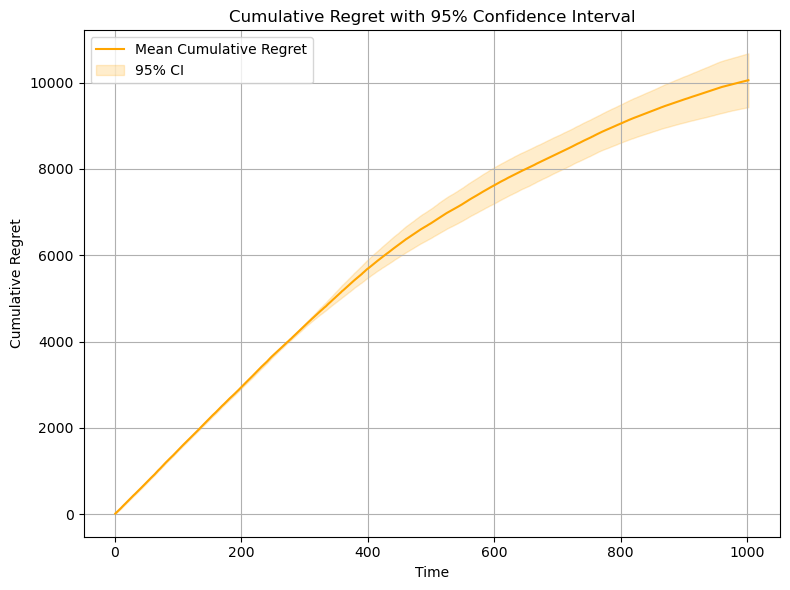

In [8]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [9]:
np.save('cumulative_regret_thresholded-lasso-bandit-d100-s5_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_thresholded-lasso-bandit-d100-s5_10times.npy', l_2_error_parameter_times)